In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path


In [3]:
# ── Copy images from Drive to Colab local disk (50x faster I/O) ─────────────
import shutil

LOCAL_IMG_DIR = Path('/content/Png')
LOCAL_IMG_DIR.mkdir(exist_ok=True)

if not any(LOCAL_IMG_DIR.iterdir()):  # skip if already copied
    print("Copying images from Drive to local disk (5-10 min, one-time)...")
    shutil.copytree(str(Path('/content/drive/MyDrive/Png')), str(LOCAL_IMG_DIR), dirs_exist_ok=True)
    print(f"Done! {len(list(LOCAL_IMG_DIR.glob('*.png')))} images copied.")
else:
    print(f"Already copied: {len(list(LOCAL_IMG_DIR.glob('*.png')))} images found locally.")


Copying images from Drive to local disk (5-10 min, one-time)...
Done! 7470 images copied.


In [ ]:
!pip install -q transformers scikit-learn

In [4]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

from transformers import ViTModel

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


In [5]:
# ── Paths ────────────────────────────────────────────────────────────────────
IMAGE_DIR = Path('/content/drive/MyDrive/Png')
CSV_PATH  = Path('/content/drive/MyDrive/dataset_labeled.csv')

# ── Label columns ────────────────────────────────────────────────────────────
LABEL_COLS = [
    'Atelectasis', 'Cardiomegaly', 'Effusion', 'Pneumonia', 'Pneumothorax',
    'Edema', 'Emphysema', 'Fibrosis', 'Infiltration', 'Mass', 'Nodule',
    'Hernia', 'Fracture', 'Pleural_Thickening', 'Opacity', 'Consolidation',
    'Granuloma', 'Calcinosis', 'Scoliosis', 'Atherosclerosis', 'Normal'
]
NUM_CLASSES = len(LABEL_COLS)

# ── Hyperparameters ──────────────────────────────────────────────────────────
IMG_SIZE     = 224    # ViT expects 224×224
BATCH_SIZE   = 16     # ViT is heavier than DenseNet, reduce if OOM
NUM_EPOCHS   = 20
LR           = 5e-5   # ViT fine-tuning needs a smaller LR
WEIGHT_DECAY = 1e-4
VAL_SPLIT    = 0.15
TEST_SPLIT   = 0.15

print(f'Number of classes: {NUM_CLASSES}')
print(f'Labels: {LABEL_COLS}')

Number of classes: 21
Labels: ['Atelectasis', 'Cardiomegaly', 'Effusion', 'Pneumonia', 'Pneumothorax', 'Edema', 'Emphysema', 'Fibrosis', 'Infiltration', 'Mass', 'Nodule', 'Hernia', 'Fracture', 'Pleural_Thickening', 'Opacity', 'Consolidation', 'Granuloma', 'Calcinosis', 'Scoliosis', 'Atherosclerosis', 'Normal']


In [6]:
df = pd.read_csv(CSV_PATH)
print(f'Total rows: {len(df)}')
print(df[LABEL_COLS].sum().sort_values(ascending=False))

Total rows: 7470
Normal                4166
Calcinosis            1026
Opacity                996
Granuloma              814
Atelectasis            731
Cardiomegaly           662
Effusion               353
Emphysema              238
Nodule                 238
Atherosclerosis        234
Edema                  207
Fracture               193
Scoliosis              179
Infiltration           176
Pneumonia              171
Pleural_Thickening     110
Hernia                  96
Fibrosis                59
Pneumothorax            54
Consolidation           53
Mass                    41
dtype: int64


In [7]:
# Verify images exist and build clean image paths
df['img_path'] = df['image_id'].apply(lambda x: str(IMAGE_DIR / x))

# Drop rows where image file is missing
missing = df[~df['img_path'].apply(os.path.exists)]
print(f'Missing images: {len(missing)}')
df = df[df['img_path'].apply(os.path.exists)].reset_index(drop=True)
print(f'Rows after dropping missing: {len(df)}')

Missing images: 0
Rows after dropping missing: 7470


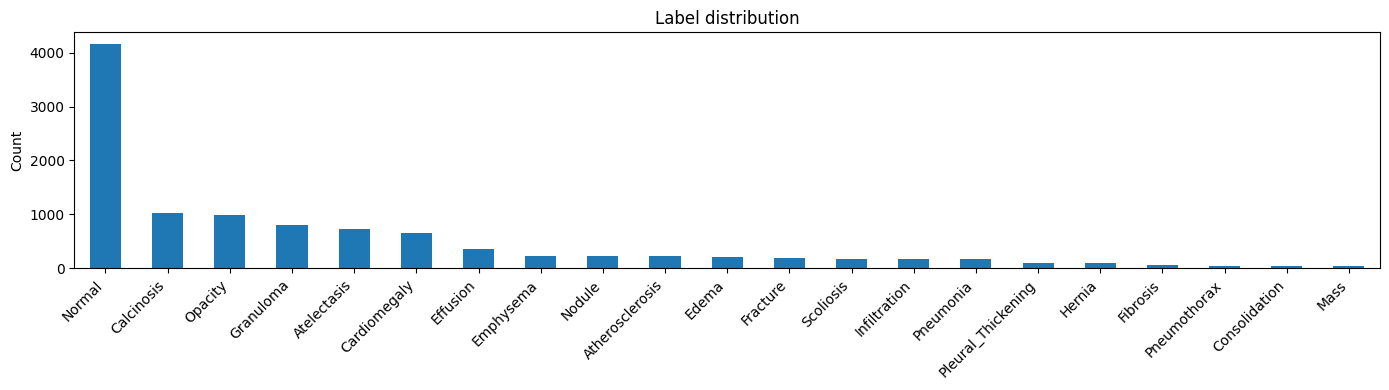

In [8]:
# Label distribution bar chart
counts = df[LABEL_COLS].sum().sort_values(ascending=False)
plt.figure(figsize=(14, 4))
counts.plot(kind='bar')
plt.title('Label distribution')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [9]:
# Stratify on the most frequent single label to keep proportions
df['primary_label'] = df[LABEL_COLS].idxmax(axis=1)

train_df, temp_df = train_test_split(
    df, test_size=(VAL_SPLIT + TEST_SPLIT), random_state=42,
    stratify=df['primary_label']
)
val_df, test_df = train_test_split(
    temp_df, test_size=TEST_SPLIT / (VAL_SPLIT + TEST_SPLIT), random_state=42,
    stratify=temp_df['primary_label']
)

print(f'Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}')

Train: 5229  Val: 1120  Test: 1121


In [10]:
# ViT models expect normalization with mean=0.5, std=0.5 (not ImageNet stats)
VIT_MEAN = [0.5, 0.5, 0.5]
VIT_STD  = [0.5, 0.5, 0.5]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=VIT_MEAN, std=VIT_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=VIT_MEAN, std=VIT_STD),
])


class ChestXRayDataset(Dataset):
    def __init__(self, dataframe, label_cols, transform=None):
        self.df         = dataframe.reset_index(drop=True)
        self.label_cols = label_cols
        self.transform  = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row['img_path']).convert('RGB')
        if self.transform:
            image = self.transform(image)
        labels = torch.tensor(row[self.label_cols].values.astype(float),
                              dtype=torch.float32)
        return image, labels


train_dataset = ChestXRayDataset(train_df, LABEL_COLS, train_transform)
val_dataset   = ChestXRayDataset(val_df,   LABEL_COLS, val_transform)
test_dataset  = ChestXRayDataset(test_df,  LABEL_COLS, val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Batches — train: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}')

Batches — train: 327, val: 70, test: 71


In [11]:
class ViTChestClassifier(nn.Module):
    """
    ViT backbone from codewithdark/vit-chest-xray (pretrained on chest X-rays),
    with a new multi-label classification head for our 21 conditions.
    """
    def __init__(self, num_classes: int):
        super().__init__()
        # Load the ViT encoder — weights already specialised for chest X-rays
        self.vit = ViTModel.from_pretrained('codewithdark/vit-chest-xray')
        hidden_size = self.vit.config.hidden_size  # 768 for ViT-base

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
            # No sigmoid — BCEWithLogitsLoss handles it
        )

    def forward(self, pixel_values):
        outputs = self.vit(pixel_values=pixel_values)
        # Use the [CLS] token (index 0) as the image representation
        cls_output = outputs.last_hidden_state[:, 0]
        return self.classifier(cls_output)


model = ViTChestClassifier(NUM_CLASSES).to(DEVICE)
print(f'ViT hidden size: {model.vit.config.hidden_size}')
print(f'Classifier head:\n{model.classifier}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/790 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: codewithdark/vit-chest-xray
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ViT hidden size: 768
Classifier head:
Sequential(
  (0): Linear(in_features=768, out_features=512, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=512, out_features=21, bias=True)
)


In [12]:
# Positive frequency per class → weight = neg_freq / pos_freq
pos_counts  = train_df[LABEL_COLS].sum().values
neg_counts  = len(train_df) - pos_counts
pos_weight  = torch.tensor(neg_counts / (pos_counts + 1e-6), dtype=torch.float32).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Two-stage training:
#   Phase 1 — only head (faster, avoids destroying pretrained features)
#   Phase 2 — fine-tune all layers with lower LR
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

print('Positive weights (first 5):', pos_weight[:5].cpu().numpy())

Positive weights (first 5): [  9.212891  10.293736  19.267443  42.575    133.07692 ]


In [13]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for images, labels in tqdm(loader, leave=False, desc='Train'):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_probs  = []
    all_labels = []
    for images, labels in tqdm(loader, leave=False, desc='Eval'):
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss   = criterion(logits, labels)
        total_loss += loss.item() * images.size(0)
        probs = torch.sigmoid(logits)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    all_probs  = np.vstack(all_probs)
    all_labels = np.vstack(all_labels)

    # Per-class AUC (skip classes with only one label value present)
    auc_scores = []
    for i in range(all_labels.shape[1]):
        if len(np.unique(all_labels[:, i])) > 1:
            auc_scores.append(roc_auc_score(all_labels[:, i], all_probs[:, i]))
        else:
            auc_scores.append(float('nan'))
    mean_auc = np.nanmean(auc_scores)

    return total_loss / len(loader.dataset), mean_auc, auc_scores

In [14]:
history   = {"train_loss": [], "val_loss": [], "val_auc": []}
best_auc  = 0.0
CKPT_PATH = '/content/drive/MyDrive/best_vit_chest.pth'
PATIENCE  = 5
no_improve = 0

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss, val_auc, _ = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Mean AUC: {val_auc:.4f}")

    if val_auc > best_auc:
        best_auc = val_auc
        no_improve = 0
        torch.save(model.state_dict(), CKPT_PATH)
        print(f"  New best AUC {best_auc:.4f} — checkpoint saved")
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"  Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)")
            break

print(f"Training complete. Best Val AUC: {best_auc:.4f}")

Train:   0%|          | 0/327 [00:00<?, ?it/s]

Eval:   0%|          | 0/70 [00:00<?, ?it/s]

Epoch 01/20 | Train Loss: 1.3056 | Val Loss: 1.2600 | Val Mean AUC: 0.5850
  New best AUC 0.5850 — checkpoint saved


Train:   0%|          | 0/327 [00:00<?, ?it/s]

Eval:   0%|          | 0/70 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/70 [00:00<?, ?it/s]

Epoch 17/20 | Train Loss: 0.4302 | Val Loss: 1.6584 | Val Mean AUC: 0.7634


Train:   0%|          | 0/327 [00:00<?, ?it/s]

Eval:   0%|          | 0/70 [00:00<?, ?it/s]

Epoch 18/20 | Train Loss: 0.4156 | Val Loss: 1.6741 | Val Mean AUC: 0.7643
  Early stopping at epoch 18 (no improvement for 5 epochs)
Training complete. Best Val AUC: 0.7697


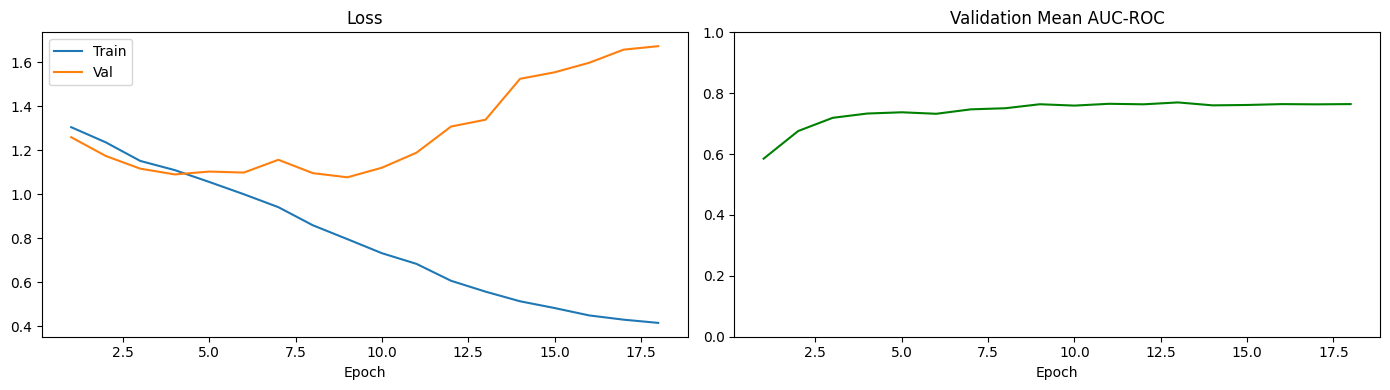

In [15]:
epochs = range(1, len(history["train_loss"]) + 1)  # actual epochs run
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(epochs, history["train_loss"], label="Train")
axes[0].plot(epochs, history["val_loss"],   label="Val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs, history["val_auc"], color="green")
axes[1].set_title("Validation Mean AUC-ROC")
axes[1].set_xlabel("Epoch")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()


In [16]:
# Load best checkpoint
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))

test_loss, test_auc, per_class_auc = evaluate(model, test_loader, criterion, DEVICE)
print(f'Test Loss: {test_loss:.4f}  |  Test Mean AUC: {test_auc:.4f}\n')

# Per-class AUC table
auc_df = pd.DataFrame({'Condition': LABEL_COLS, 'AUC-ROC': per_class_auc})
auc_df = auc_df.sort_values('AUC-ROC', ascending=False).reset_index(drop=True)
print(auc_df.to_string(index=False))

Eval:   0%|          | 0/71 [00:00<?, ?it/s]

Test Loss: 1.3912  |  Test Mean AUC: 0.7731

         Condition  AUC-ROC
     Consolidation 0.922619
            Hernia 0.915440
         Emphysema 0.912468
      Cardiomegaly 0.896122
             Edema 0.873969
          Effusion 0.870031
      Infiltration 0.843361
       Atelectasis 0.830069
           Opacity 0.809710
              Mass 0.805979
   Atherosclerosis 0.802141
         Pneumonia 0.778082
            Normal 0.762118
Pleural_Thickening 0.736879
          Fibrosis 0.717192
      Pneumothorax 0.677758
        Calcinosis 0.662757
         Granuloma 0.634833
            Nodule 0.611830
          Fracture 0.610666
         Scoliosis 0.560803
